## **UCUCI Bank Loan Portfolio Health & Repayment Performance Analysis**

# **Business Problem Overview**

###**Improving Loan Repayment Rate and Portfolio Health at UCUCI Bank**

UCUCI Bank offers retail lending products such as personal loans, credit card loans, and debt consolidation financing. As the loan portfolio grows, the bank needs to understand which borrowers repay successfully and which segments create delinquency or default risk.
The analysis focuses on repayment behaviour, risk grades, borrower financial profile, interest rate pricing, and recovery performance. The primary business goal is to improve the Loan Repayment Rate while supporting better risk pricing and credit policy decisions.

**Objective:**

In this project, we aim to analyze UCUCI Bank loan data to:

1. Measure the overall Loan Repayment Rate.
2. Identify borrower and loan segments with higher default risk.
3. Evaluate whether interest rates increase appropriately across loan grades and sub-grades.
4. Understand repayment performance by grade, term, income, DTI, purpose, and verification status.
5. Measure recovery efficiency for charged-off loans.
6. Recommend actions to improve portfolio quality and repayment outcomes.







**Business Impact:**

1. This analysis will help UCUCI Bank:
2. Improve credit-risk monitoring and early warning indicators.
3. Strengthen grade-based and sub-grade-based risk pricing.
4. Reduce avoidable defaults and charged-off loans.
5. Improve provisioning efficiency.
6. Support sustainable growth in the retail loan portfolio.


# **Dataset Overview**

### **Dataset:**

- **Dataset Name:** UCUCI Bank Loan Portfolio Dataset

- **Number of Rows:** 887,379

- **Number of Columns:** 57

- **Description:** The dataset contains loan-level information including funded amount, loan status, grade, sub-grade, borrower income, debt-to-income ratio, interest rate, installment, repayment amount, outstanding principal, and recoveries.

### **Key Column Definitions:**

1. **id**: Unique loan identifier.
2. **member_id**: Unique borrower identifier.
3. **loan_amnt**: Total loan amount applied for.
4. **funded_amnt**: Actual amount funded.
5. **funded_amnt_inv**: Amount funded by investors.
6. **term**: Loan repayment duration.
7. **int_rate**: Annual interest rate charged on the loan.
8. **installment**: Fixed monthly installment.
9. **grade**: Loan risk grade.
10. **sub_grade**: Granular risk tier within grade.
11. **emp_title**: Borrower employment title.
12. **emp_length**: Borrower employment length.
13. **home_ownership**: Borrower home ownership status.
14. **annual_inc**: Borrower annual income.
15. **verification_status**: Income verification status.
16. **issue_d**: Month and year when loan was issued.
17. **loan_status**: Current repayment status.
18. **purpose**: Borrower-stated loan purpose.
19. **addr_state**: Borrower state or region.
20. **dti**: Debt-to-income ratio.
21. **delinq_2yrs**: Number of recent delinquencies.
22. **inq_last_6mths**: Credit inquiries in last six months.
23. **mths_since_last_delinq**: Months since last delinquency.
24. **mths_since_last_record**: Months since last public derogatory record.
25. **open_acc**: Number of open credit lines.
26. **pub_rec**: Number of public derogatory records.
27. **revol_bal**: Revolving balance.
28. **revol_util**: Revolving utilization rate.
29. **total_acc**: Total credit lines.
30. **total_pymnt**: Total amount repaid.
31. **recoveries**: Amount recovered after default.
32. **out_prncp**: Outstanding principal.



# **Analysis & Visualisatio**

## ***1. Importing and Cleaning Data***

### Importing Necessary Libraries

In [4]:
!pip install gdown


In [5]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Loading the Dataset from google drive

In [6]:
file_id = "1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8"
download_url = f"https://drive.google.com/uc?id={file_id}"

In [7]:
output_file = "UCUCI_dataset.csv"


In [8]:
gdown.download(download_url, output_file, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8
From (redirected): https://drive.google.com/uc?id=1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8&confirm=t&uuid=574ca308-3c9b-4b94-9018-5293fa50889d
To: /content/UCUCI_dataset.csv
100%|██████████| 411M/411M [00:05<00:00, 68.7MB/s]


'UCUCI_dataset.csv'

In [9]:
data = pd.read_csv(output_file, low_memory=False)

#### Viewing the First Few Rows of the Dataset


In [10]:
print("First 5 Rows of the Dataset:")
data.head()

First 5 Rows of the Dataset:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,Sep-2013,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,Jan-2015,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,Feb-2016,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0


### Checking the Shape of the Dataset


In [11]:
rows, columns = data.shape
print(f"The dataset contains {rows:,} rows and {columns:,} columns.")

The dataset contains 887,379 rows and 57 columns.


### Displaying Dataset Information


In [12]:
print("Dataset Information:")
data.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           887379 non-null  int64  
 1   member_id                    887379 non-null  int64  
 2   loan_amnt                    887379 non-null  float64
 3   funded_amnt                  887379 non-null  float64
 4   funded_amnt_inv              887379 non-null  float64
 5   term                         887379 non-null  object 
 6   int_rate                     887379 non-null  float64
 7   installment                  887379 non-null  float64
 8   grade                        887379 non-null  object 
 9   sub_grade                    887379 non-null  object 
 10  emp_title                    835917 non-null  object 
 11  emp_length                   842554 non-null  object 
 12  home_ownership               887379 n

#### Checking for Duplicate Values in the Dataset


In [13]:
duplicate_count = data.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicate_count:,}")

if "id" in data.columns:
    duplicate_id_count = data["id"].duplicated().sum()
    print(f"Number of duplicate loan IDs: {duplicate_id_count:,}")

if "member_id" in data.columns:
    duplicate_member_count = data["member_id"].duplicated().sum()
    print(f"Number of duplicate member IDs: {duplicate_member_count:,}")

Number of duplicate rows in the dataset: 0
Number of duplicate loan IDs: 0
Number of duplicate member IDs: 0


#### Checking for Missing/Null Values


In [14]:
missing_values = data.isnull().sum().sort_values(ascending=False)
missing_percentage = ((data.isnull().sum() / len(data)) * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})

print("Missing/Null Values by Column:")
missing_summary

Missing/Null Values by Column:


,Missing Values,Missing Percentage
dti_joint,886870,99.94
annual_inc_joint,886868,99.94
verification_status_joint,886868,99.94
desc,761353,85.80
mths_since_last_record,750326,84.56
mths_since_last_major_derog,665676,75.02
mths_since_last_delinq,454312,51.20
next_pymnt_d,252971,28.51
emp_title,51462,5.80
emp_length,44825,5.05


In [15]:
# Checking text-like blank values because some blank strings may not appear as null values
blank_summary = pd.DataFrame({
    "Blank String Count": [(data[col].astype(str).str.strip() == "").sum() for col in data.columns]
}, index=data.columns)

blank_summary["Blank String Percentage"] = ((blank_summary["Blank String Count"] / len(data)) * 100).round(2)
blank_summary = blank_summary.sort_values(by="Blank String Count", ascending=False)

print("Blank String Check:")
blank_summary

Blank String Check:


,Blank String Count,Blank String Percentage
desc,247,0.03
member_id,0,0.00
loan_amnt,0,0.00
funded_amnt,0,0.00
funded_amnt_inv,0,0.00
term,0,0.00
int_rate,0,0.00
installment,0,0.00
id,0,0.00
grade,0,0.00


In [16]:
# Missing value interpretation for business analysis
meaningful_blank_notes = pd.DataFrame({
    "Column": [
        "annual_inc_joint",
        "dti_joint",
        "verification_status_joint",
        "mths_since_last_delinq",
        "mths_since_last_record",
        "desc",
        "emp_title",
        "emp_length"
    ],
    "Interpretation": [
        "Mostly blank when the loan is an individual application, so blank means not applicable.",
        "Mostly blank when the loan is an individual application, so blank means not applicable.",
        "Mostly blank when the loan is an individual application, so blank means not applicable.",
        "Blank may indicate no recorded previous delinquency.",
        "Blank may indicate no public derogatory record.",
        "Optional borrower-provided description; not critical for KPI calculation.",
        "Optional employment title; useful for profiling but not critical for core KPIs.",
        "Employment length may be unknown; can be grouped as Unknown."
    ]
})

meaningful_blank_notes

,Column,Interpretation
0,annual_inc_joint,Mostly blank when the loan is an individual ap...
1,dti_joint,Mostly blank when the loan is an individual ap...
2,verification_status_joint,Mostly blank when the loan is an individual ap...
3,mths_since_last_delinq,Blank may indicate no recorded previous delinq...
4,mths_since_last_record,Blank may indicate no public derogatory record.
5,desc,Optional borrower-provided description; not cr...
6,emp_title,Optional employment title; useful for profilin...
7,emp_length,Employment length may be unknown; can be group...


### Summary of Dataset Observations


In [17]:
print("Observations About the Dataset:")
print(f"1. The dataset contains {rows:,} records and {columns:,} columns.")
print(f"2. Duplicate row count is {duplicate_count:,}.")

if "id" in data.columns:
    print(f"3. Duplicate loan ID count is {data['id'].duplicated().sum():,}.")

if "loan_status" in data.columns:
    print("4. Loan status distribution:")
    print(data["loan_status"].value_counts(dropna=False))

print("5. Core KPI fields should be reviewed for missing values before KPI calculation.")

Observations About the Dataset:
1. The dataset contains 887,379 records and 57 columns.
2. Duplicate row count is 0.
3. Duplicate loan ID count is 0.
4. Loan status distribution:
loan_status
Current                                                601779
Fully Paid                                             207723
Charged Off                                             45248
Late (31-120 days)                                      11591
Issued                                                   8460
In Grace Period                                          6253
Late (16-30 days)                                        2357
Does not meet the credit policy. Status:Fully Paid       1988
Default                                                  1219
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64
5. Core KPI fields should be reviewed for missing values before KPI calculation.


## ***2. Data Types***

In [18]:
# Dataset Columns
print("Dataset Columns:")
for column in data.columns:
    print(column)

Dataset Columns:
id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq


In [19]:
# Dataset Describe
print("Statistical Summary of Numeric Columns:")
data.describe()

Statistical Summary of Numeric Columns:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq
count,8.873790e+05,8.873790e+05,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,8.873750e+05,887379.000000,887350.000000,...,887379.000000,887379.000000,887379.000000,887379.000000,887234.000000,221703.000000,887379.0,511.000000,509.000000,887350.000000
mean,3.246513e+07,3.500182e+07,14755.264605,14741.877625,14702.464383,13.246740,436.717127,7.502759e+04,18.157039,0.314442,...,0.396692,45.919243,4.880757,2164.145585,0.014380,44.104838,1.0,109981.011585,18.310118,0.004991
std,2.282734e+07,2.411335e+07,8435.455601,8429.897657,8442.106732,4.381867,244.186593,6.469830e+04,17.190626,0.862244,...,4.087825,409.693874,63.125281,4794.783233,0.134191,22.179841,0.0,52730.379847,7.169233,0.077625
min,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.320000,15.670000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,17950.000000,3.000000,0.000000
25%,9.206643e+06,1.087713e+07,8000.000000,8000.000000,8000.000000,9.990000,260.705000,4.500000e+04,11.910000,0.000000,...,0.000000,0.000000,0.000000,280.170000,0.000000,27.000000,1.0,76032.500000,13.200000,0.000000
50%,3.443327e+07,3.709528e+07,13000.000000,13000.000000,13000.000000,12.990000,382.550000,6.500000e+04,17.650000,0.000000,...,0.000000,0.000000,0.000000,462.780000,0.000000,44.000000,1.0,101771.000000,17.610000,0.000000
75%,5.490814e+07,5.847135e+07,20000.000000,20000.000000,20000.000000,16.200000,572.600000,9.000000e+04,23.950000,0.000000,...,0.000000,0.000000,0.000000,831.245000,0.000000,61.000000,1.0,132800.000000,22.650000,0.000000
max,6.861706e+07,7.354484e+07,35000.000000,35000.000000,35000.000000,28.990000,1445.460000,9.500000e+06,9999.000000,39.000000,...,358.680000,33520.270000,7002.190000,36475.590000,20.000000,188.000000,1.0,500000.000000,43.860000,14.000000


In [20]:
# Variables Description
variables_description = pd.DataFrame({
    "Variable": [
        "funded_amnt",
        "total_pymnt",
        "loan_status",
        "grade",
        "sub_grade",
        "int_rate",
        "recoveries",
        "out_prncp",
        "annual_inc",
        "dti",
        "term",
        "installment",
        "purpose",
        "verification_status"
    ],
    "Description": [
        "Actual approved and funded loan amount.",
        "Total payment received from borrower.",
        "Current repayment status of the loan.",
        "Risk grade assigned to the loan.",
        "Detailed risk tier within grade.",
        "Annual interest rate charged.",
        "Amount recovered after default.",
        "Outstanding principal.",
        "Borrower's annual income.",
        "Borrower's debt-to-income ratio.",
        "Loan repayment duration.",
        "Monthly installment amount.",
        "Stated loan purpose.",
        "Income verification status."
    ],
    "Importance for Analysis": [
        "Used as denominator for LRR.",
        "Used as numerator for LRR.",
        "Used to identify fully paid, current, defaulted, and delinquent loans.",
        "Used for risk segmentation.",
        "Used for detailed risk segmentation.",
        "Used to evaluate risk-based pricing.",
        "Used for recovery-rate calculation.",
        "Used for recovery-rate calculation.",
        "Used to profile borrower repayment capacity.",
        "Used to profile debt burden.",
        "Used to compare repayment performance by loan duration.",
        "Used to understand monthly repayment pressure.",
        "Used to identify risky loan purposes.",
        "Used to assess verified vs non-verified borrower behaviour."
    ]
})

variables_description

,Variable,Description,Importance for Analysis
0,funded_amnt,Actual approved and funded loan amount.,Used as denominator for LRR.
1,total_pymnt,Total payment received from borrower.,Used as numerator for LRR.
2,loan_status,Current repayment status of the loan.,"Used to identify fully paid, current, defaulte..."
3,grade,Risk grade assigned to the loan.,Used for risk segmentation.
4,sub_grade,Detailed risk tier within grade.,Used for detailed risk segmentation.
5,int_rate,Annual interest rate charged.,Used to evaluate risk-based pricing.
6,recoveries,Amount recovered after default.,Used for recovery-rate calculation.
7,out_prncp,Outstanding principal.,Used for recovery-rate calculation.
8,annual_inc,Borrower's annual income.,Used to profile borrower repayment capacity.
9,dti,Borrower's debt-to-income ratio.,Used to profile debt burden.


### Unique Values for each variable.

In [21]:
# Unique Values for Each Variable
unique_values_summary = pd.DataFrame({
    "Column": data.columns,
    "Unique Values": [data[col].nunique(dropna=False) for col in data.columns]
}).sort_values(by="Unique Values", ascending=False)

unique_values_summary

,Column,Unique Values
0,id,887379
1,member_id,887379
18,url,887379
38,total_pymnt,506726
39,total_pymnt_inv,506616
41,total_rec_int,324635
10,emp_title,299272
37,out_prncp_inv,266244
40,total_rec_prncp,260227
36,out_prncp,248332


In [22]:
# Display unique values for important categorical columns
categorical_columns = [
    "loan_status",
    "grade",
    "sub_grade",
    "term",
    "home_ownership",
    "verification_status",
    "purpose",
    "application_type"
]

for col in categorical_columns:
    if col in data.columns:
        print(f"\nUnique values in {col}:")
        print(data[col].value_counts(dropna=False))


Unique values in loan_status:
loan_status
Current                                                601779
Fully Paid                                             207723
Charged Off                                             45248
Late (31-120 days)                                      11591
Issued                                                   8460
In Grace Period                                          6253
Late (16-30 days)                                        2357
Does not meet the credit policy. Status:Fully Paid       1988
Default                                                  1219
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

Unique values in grade:
grade
B    254535
C    245860
A    148202
D    139542
E     70705
F     23046
G      5489
Name: count, dtype: int64

Unique values in sub_grade:
sub_grade
B3    56323
B4    55626
C1    53387
C2    52236
C3    50161
C4    48857
B5    48833
B2    48781
B1    44972
A5    44816
C5    41219

## 3. ***Data Wrangling***


### Data Wrangling Code

In [23]:
# Copying the dataset for analysis
loan_data = data.copy()
print("Data copied successfully for analysis.")

Data copied successfully for analysis.


In [24]:
# Standardizing column names
loan_data.columns = loan_data.columns.str.strip().str.lower().str.replace(" ", "_")
print("Column names standardized.")

Column names standardized.


In [25]:
# Validating required KPI columns before analysis
required_kpi_columns = [
    "funded_amnt",
    "total_pymnt",
    "loan_status",
    "grade",
    "sub_grade",
    "int_rate",
    "recoveries",
    "out_prncp"
]

missing_required_columns = [col for col in required_kpi_columns if col not in loan_data.columns]

if len(missing_required_columns) == 0:
    print("Required KPI column validation passed.")
else:
    print("Required KPI column validation failed.")
    print("Missing columns:", missing_required_columns)
    raise ValueError("The dataset does not contain all required KPI columns. Please verify the uploaded CSV file.")

Required KPI column validation passed.


In [26]:
# Converting important numeric columns to numeric format
numeric_columns = [
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "mths_since_last_delinq",
    "mths_since_last_record",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "total_pymnt",
    "recoveries",
    "out_prncp"
]

for col in numeric_columns:
    if col in loan_data.columns:
        loan_data[col] = pd.to_numeric(loan_data[col], errors="coerce")

print("Important numeric columns converted successfully.")

Important numeric columns converted successfully.


In [27]:
# Cleaning categorical columns by removing extra spaces
categorical_columns = [
    "term",
    "grade",
    "sub_grade",
    "home_ownership",
    "verification_status",
    "loan_status",
    "purpose",
    "application_type"
]

for col in categorical_columns:
    if col in loan_data.columns:
        loan_data[col] = loan_data[col].astype(str).str.strip()

print("Important categorical columns cleaned successfully.")

Important categorical columns cleaned successfully.


In [28]:
# Handling missing values for analysis-friendly fields
if "emp_title" in loan_data.columns:
    loan_data["emp_title"] = loan_data["emp_title"].fillna("Unknown")
    loan_data["emp_title"] = loan_data["emp_title"].replace("", "Unknown")

if "emp_length" in loan_data.columns:
    loan_data["emp_length"] = loan_data["emp_length"].fillna("Unknown")
    loan_data["emp_length"] = loan_data["emp_length"].replace("", "Unknown")

if "mths_since_last_delinq" in loan_data.columns:
    loan_data["has_prior_delinq"] = loan_data["mths_since_last_delinq"].notnull()
    loan_data["mths_since_last_delinq_filled"] = loan_data["mths_since_last_delinq"].fillna(0)

if "mths_since_last_record" in loan_data.columns:
    loan_data["has_public_record"] = loan_data["mths_since_last_record"].notnull()
    loan_data["mths_since_last_record_filled"] = loan_data["mths_since_last_record"].fillna(0)

if "annual_inc" in loan_data.columns:
    loan_data["annual_inc_missing_flag"] = loan_data["annual_inc"].isnull()

if "revol_util" in loan_data.columns:
    loan_data["revol_util_missing_flag"] = loan_data["revol_util"].isnull()

print("Missing values handled using business-friendly flags and Unknown categories.")

Missing values handled using business-friendly flags and Unknown categories.


In [29]:
# Creating repayment outcome flags
loan_data["is_charged_off"] = loan_data["loan_status"].eq("Charged Off")
loan_data["is_fully_paid"] = loan_data["loan_status"].eq("Fully Paid")
loan_data["is_current"] = loan_data["loan_status"].eq("Current")
loan_data["is_late"] = loan_data["loan_status"].isin(["Late (31-120 days)", "Late (16-30 days)", "In Grace Period"])

print("Repayment outcome flags created.")

Repayment outcome flags created.


In [30]:
# Creating simplified loan status categories for stakeholder analysis
def classify_loan_status(status):
    if status == "Fully Paid":
        return "Fully Paid"
    elif status == "Current":
        return "Good Standing"
    elif status in ["Late (31-120 days)", "Late (16-30 days)", "In Grace Period"]:
        return "Delinquent"
    elif status in ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off"]:
        return "Defaulted"
    elif status == "Issued":
        return "Newly Issued"
    elif status == "Does not meet the credit policy. Status:Fully Paid":
        return "Fully Paid - Policy Exception"
    else:
        return "Other"

loan_data["loan_status_group"] = loan_data["loan_status"].apply(classify_loan_status)

print("Simplified loan status groups created.")
print(loan_data["loan_status_group"].value_counts())

Simplified loan status groups created.
loan_status_group
Good Standing                    601779
Fully Paid                       207723
Defaulted                         47228
Delinquent                        20201
Newly Issued                       8460
Fully Paid - Policy Exception      1988
Name: count, dtype: int64


In [31]:
# Creating issue date features for time-based trend analysis
if "issue_d" in loan_data.columns:
    loan_data["issue_date"] = pd.to_datetime(loan_data["issue_d"], format="%b-%Y", errors="coerce")
    loan_data["issue_year"] = loan_data["issue_date"].dt.year
    loan_data["issue_month"] = loan_data["issue_date"].dt.month
    loan_data["issue_year_month"] = loan_data["issue_date"].dt.to_period("M").astype(str)

print("Issue date features created for trend analysis.")

Issue date features created for trend analysis.


In [32]:
# Creating core KPI fields
loan_data["loan_repayment_rate"] = (loan_data["total_pymnt"] / loan_data["funded_amnt"]) * 100

# Loan-level recovery rate is defined only where outstanding principal is greater than zero.
# Where out_prncp is zero, the recovery rate cannot be calculated using the project formula.
loan_data["recovery_rate"] = np.nan
loan_data.loc[loan_data["out_prncp"] > 0, "recovery_rate"] = (
    loan_data.loc[loan_data["out_prncp"] > 0, "recoveries"] /
    loan_data.loc[loan_data["out_prncp"] > 0, "out_prncp"]
) * 100

print("KPI fields created successfully.")

KPI fields created successfully.


In [33]:
# Creating analysis-safe outlier flags without deleting records
loan_data["is_high_dti"] = loan_data["dti"] > 40
loan_data["is_extreme_dti"] = loan_data["dti"] > 100
loan_data["is_high_income"] = loan_data["annual_inc"] > 1000000
loan_data["is_extreme_lrr"] = loan_data["loan_repayment_rate"] > 200

if "revol_util" in loan_data.columns:
    loan_data["is_high_revol_util"] = loan_data["revol_util"] > 100

outlier_flag_summary = pd.DataFrame({
    "Flag": [
        "is_high_dti",
        "is_extreme_dti",
        "is_high_income",
        "is_extreme_lrr",
        "is_high_revol_util"
    ],
    "Record Count": [
        loan_data["is_high_dti"].sum(),
        loan_data["is_extreme_dti"].sum(),
        loan_data["is_high_income"].sum(),
        loan_data["is_extreme_lrr"].sum(),
        loan_data["is_high_revol_util"].sum() if "is_high_revol_util" in loan_data.columns else 0
    ]
})

outlier_flag_summary

,Flag,Record Count
0,is_high_dti,90
1,is_extreme_dti,11
2,is_high_income,153
3,is_extreme_lrr,0
4,is_high_revol_util,3506


In [34]:
# Creating borrower income bands
income_bins = [0, 30000, 60000, 100000, 150000, 250000, loan_data["annual_inc"].max()]
income_labels = [
    "Very Low Income",
    "Low Income",
    "Middle Income",
    "Upper Middle Income",
    "High Income",
    "Very High Income"
]

loan_data["income_band"] = pd.cut(
    loan_data["annual_inc"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

print("Income bands created.")

Income bands created.


In [35]:
# Creating DTI bands
dti_bins = [0, 10, 20, 30, 40, loan_data["dti"].max()]
dti_labels = [
    "Low DTI",
    "Moderate DTI",
    "High DTI",
    "Very High DTI",
    "Extreme DTI"
]

loan_data["dti_band"] = pd.cut(
    loan_data["dti"],
    bins=dti_bins,
    labels=dti_labels,
    include_lowest=True
)

print("DTI bands created.")

DTI bands created.


In [36]:
# Creating additional business-friendly bands
loan_amount_bins = [0, 5000, 10000, 15000, 25000, loan_data["funded_amnt"].max()]
loan_amount_labels = [
    "Very Small Loan",
    "Small Loan",
    "Medium Loan",
    "Large Loan",
    "Very Large Loan"
]

loan_data["loan_amount_band"] = pd.cut(
    loan_data["funded_amnt"],
    bins=loan_amount_bins,
    labels=loan_amount_labels,
    include_lowest=True
)

interest_rate_bins = [0, 8, 12, 16, 20, loan_data["int_rate"].max()]
interest_rate_labels = [
    "Very Low Rate",
    "Low Rate",
    "Moderate Rate",
    "High Rate",
    "Very High Rate"
]

loan_data["interest_rate_band"] = pd.cut(
    loan_data["int_rate"],
    bins=interest_rate_bins,
    labels=interest_rate_labels,
    include_lowest=True
)

loan_data["monthly_income"] = loan_data["annual_inc"] / 12
loan_data["installment_to_income_pct"] = np.where(
    loan_data["monthly_income"] > 0,
    (loan_data["installment"] / loan_data["monthly_income"]) * 100,
    np.nan
)

installment_burden_bins = [0, 5, 10, 20, 30, loan_data["installment_to_income_pct"].max()]
installment_burden_labels = [
    "Very Low Burden",
    "Low Burden",
    "Moderate Burden",
    "High Burden",
    "Very High Burden"
]

loan_data["installment_burden_band"] = pd.cut(
    loan_data["installment_to_income_pct"],
    bins=installment_burden_bins,
    labels=installment_burden_labels,
    include_lowest=True
)

print("Loan amount, interest rate, and installment burden bands created.")

Loan amount, interest rate, and installment burden bands created.


In [37]:
# Checking basic statistics after wrangling
important_numeric_fields = [
    "funded_amnt",
    "total_pymnt",
    "loan_repayment_rate",
    "int_rate",
    "annual_inc",
    "dti",
    "recoveries",
    "out_prncp",
    "recovery_rate"
]

loan_data[important_numeric_fields].describe()

,funded_amnt,total_pymnt,loan_repayment_rate,int_rate,annual_inc,dti,recoveries,out_prncp,recovery_rate
count,887379.000000,887379.000000,887379.000000,887379.000000,8.873750e+05,887379.000000,887379.000000,887379.000000,631581.0
mean,14741.877625,7558.826684,53.910845,13.246740,7.502759e+04,18.157039,45.919243,8403.124852,0.0
std,8429.897657,7871.243336,41.913005,4.381867,6.469830e+04,17.190626,409.693874,8493.450269,0.0
min,500.000000,0.000000,0.000000,5.320000,0.000000e+00,0.000000,0.000000,0.000000,0.0
25%,8000.000000,1914.590000,16.702000,9.990000,4.500000e+04,11.910000,0.000000,0.000000,0.0
50%,13000.000000,4894.999117,41.115040,12.990000,6.500000e+04,17.650000,0.000000,6458.290000,0.0
75%,20000.000000,10616.814231,101.695378,16.200000,9.000000e+04,23.950000,0.000000,13659.055000,0.0
max,35000.000000,57777.579870,168.885204,28.990000,9.500000e+06,9999.000000,33520.270000,49372.860000,0.0


In [38]:
# Identifying records with potential outliers for review
outlier_review = pd.DataFrame({
    "Condition": [
        "DTI greater than 100",
        "Revolving utilization greater than 100",
        "Annual income greater than 1,000,000",
        "Loan repayment rate greater than 200"
    ],
    "Record Count": [
        (loan_data["dti"] > 100).sum() if "dti" in loan_data.columns else 0,
        (loan_data["revol_util"] > 100).sum() if "revol_util" in loan_data.columns else 0,
        (loan_data["annual_inc"] > 1000000).sum() if "annual_inc" in loan_data.columns else 0,
        (loan_data["loan_repayment_rate"] > 200).sum() if "loan_repayment_rate" in loan_data.columns else 0
    ]
})

outlier_review

,Condition,Record Count
0,DTI greater than 100,11
1,Revolving utilization greater than 100,3506
2,"Annual income greater than 1,000,000",153
3,Loan repayment rate greater than 200,0


## 4. ***Exploratory Data Analysis (EDA)***

**Goal of EDA**

The goal of Exploratory Data Analysis is to identify trends, patterns, outliers, and relationships in the loan portfolio. The EDA is structured into:
1. Univariate Analysis: Study individual columns such as loan amount, interest rate, income, DTI, and loan status.
2. Bivariate Analysis: Study relationships between two variables such as grade vs default rate or interest rate vs repayment rate.
3. Multivariate Analysis: Study interactions between multiple variables such as grade, term, DTI band, default rate, and LRR together.

**4.1.  Univariate Analysis**

**Distribution of Loan Amount**

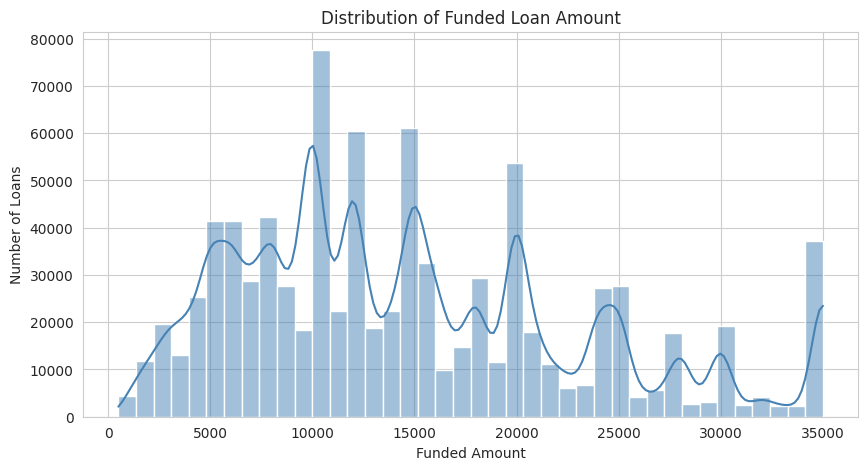

In [39]:
plt.figure(figsize=(10, 5))
sns.histplot(loan_data["funded_amnt"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Funded Loan Amount")
plt.xlabel("Funded Amount")
plt.ylabel("Number of Loans")
plt.show()

**Distribution of Debt-to-Income Ratio**

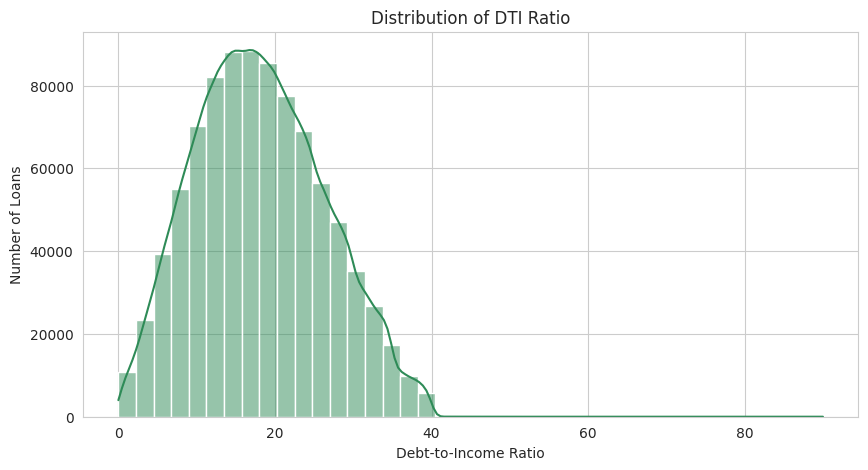

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(loan_data[loan_data["dti"] <= 100]["dti"], bins=40, kde=True, color="seagreen")
plt.title("Distribution of DTI Ratio")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Number of Loans")
plt.show()

**Distribution of Annual Income**

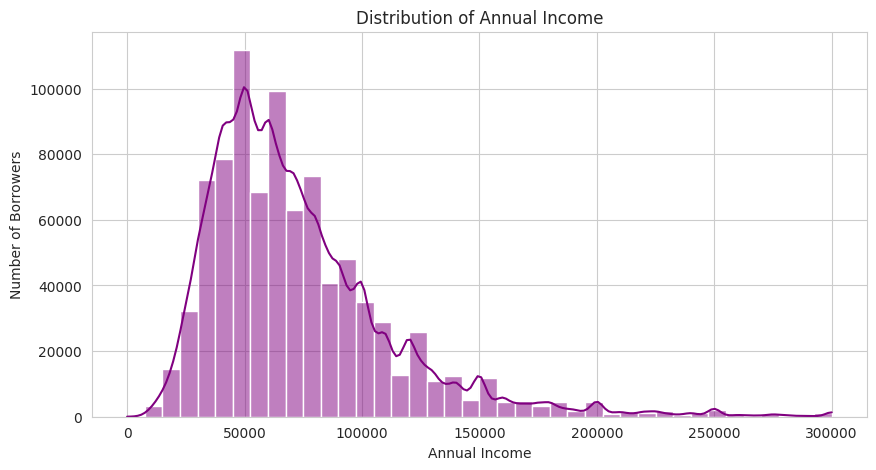

In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(loan_data[loan_data["annual_inc"] <= 300000]["annual_inc"], bins=40, kde=True, color="purple")
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of Borrowers")
plt.show()

**Loan Status Count**

/tmp/ipykernel_474/3450337708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=loan_data, y="loan_status", order=loan_status_order, palette="viridis")


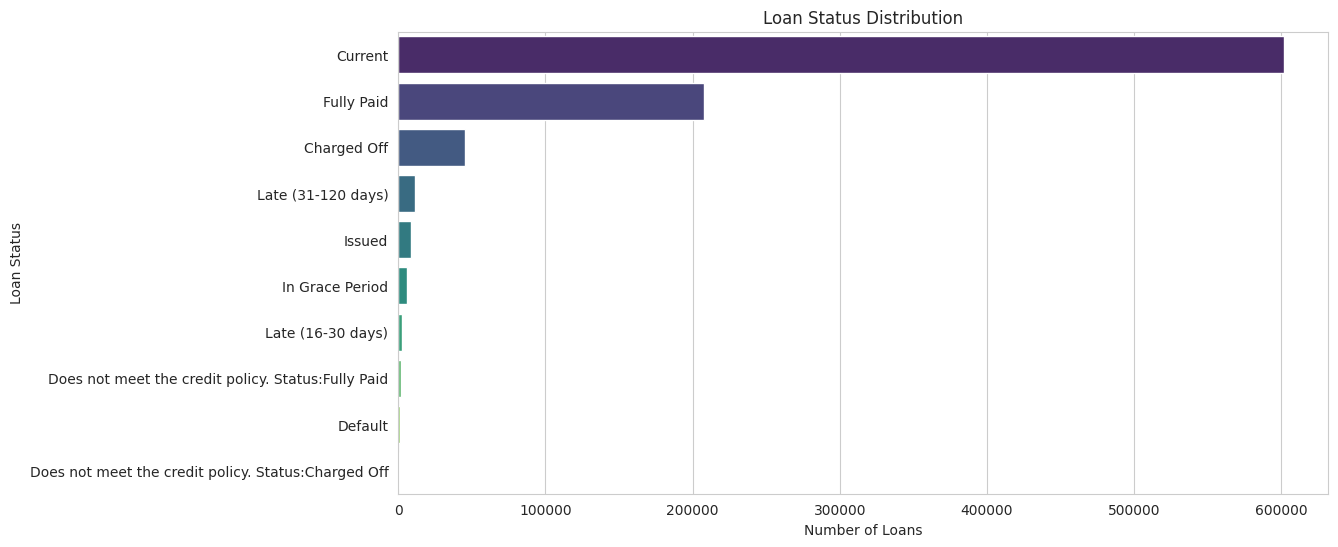

In [42]:
plt.figure(figsize=(12, 6))
loan_status_order = loan_data["loan_status"].value_counts().index
sns.countplot(data=loan_data, y="loan_status", order=loan_status_order, palette="viridis")
plt.title("Loan Status Distribution")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Status")
plt.show()

**Boxplot for Outlier Detection**

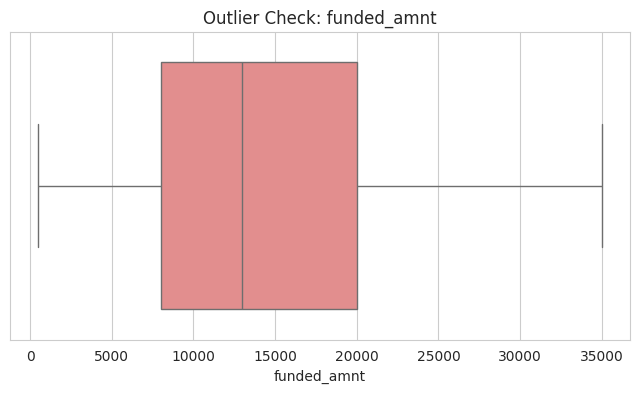

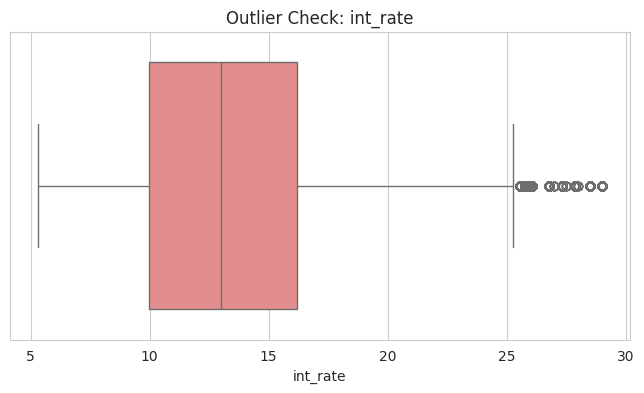

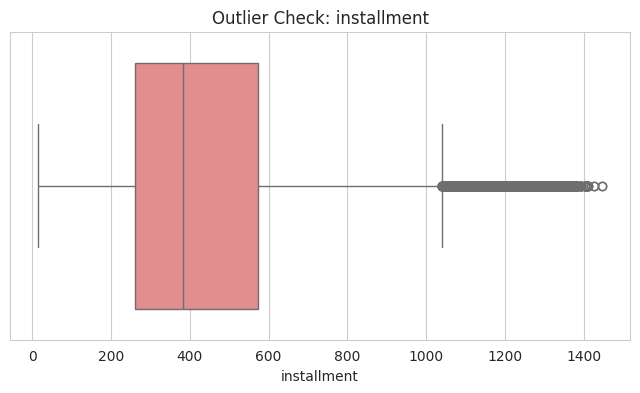

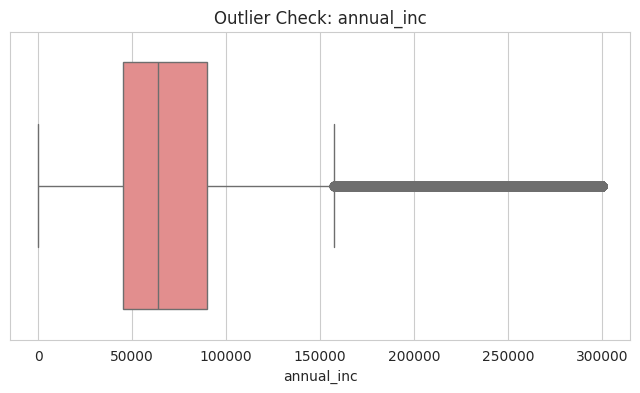

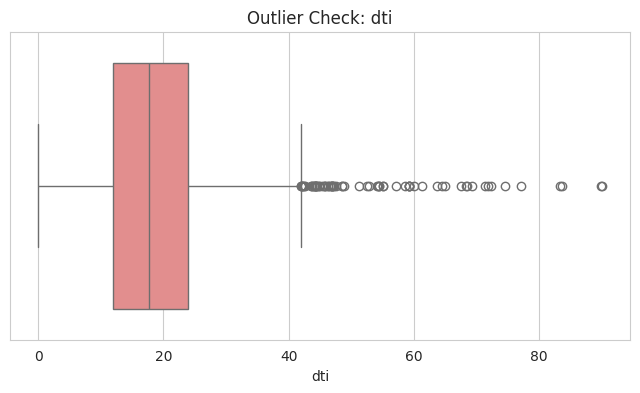

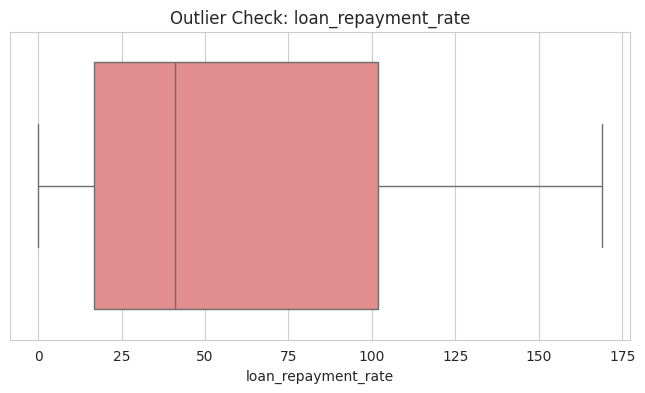

In [43]:
outlier_columns = ["funded_amnt", "int_rate", "installment", "annual_inc", "dti", "loan_repayment_rate"]

for col in outlier_columns:
    plt.figure(figsize=(8, 4))
    if col == "annual_inc":
        plot_data = loan_data[loan_data[col] <= 300000]
    elif col == "dti":
        plot_data = loan_data[loan_data[col] <= 100]
    elif col == "loan_repayment_rate":
        plot_data = loan_data[loan_data[col] <= 250]
    else:
        plot_data = loan_data

    sns.boxplot(x=plot_data[col], color="lightcoral")
    plt.title(f"Outlier Check: {col}")
    plt.xlabel(col)
    plt.show()

**4.2 Bivariate Analysis**

**Average Interest Rate by Grade**

/tmp/ipykernel_474/3672921828.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_interest_by_grade, x="grade", y="int_rate", palette="Blues_d")


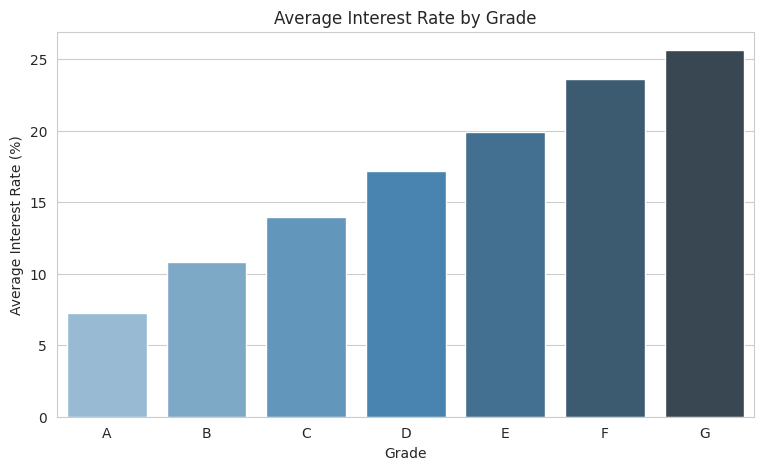

In [44]:
eda_interest_by_grade = loan_data.groupby("grade", dropna=False)["int_rate"].mean().reset_index()
eda_interest_by_grade = eda_interest_by_grade.sort_values(by="grade")

plt.figure(figsize=(9, 5))
sns.barplot(data=eda_interest_by_grade, x="grade", y="int_rate", palette="Blues_d")
plt.title("Average Interest Rate by Grade")
plt.xlabel("Grade")
plt.ylabel("Average Interest Rate (%)")
plt.show()

**Default Rate by Grade**

/tmp/ipykernel_474/4068863664.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_default_by_grade, x="grade", y="default_rate", palette="Reds_d")


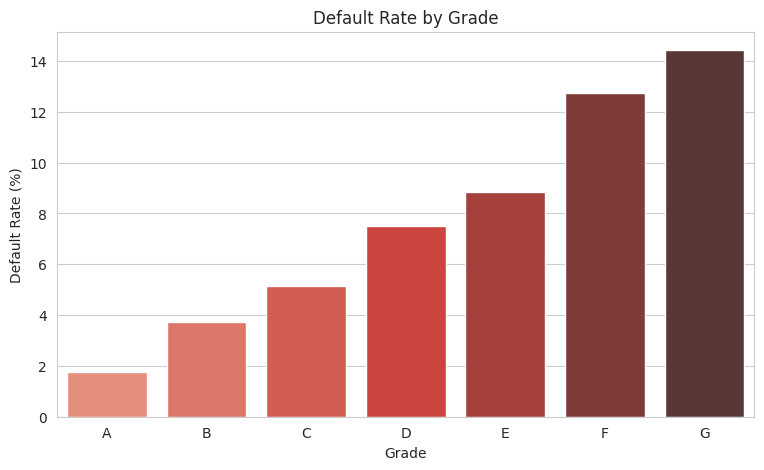

In [45]:
eda_default_by_grade = loan_data.groupby("grade", dropna=False)["is_charged_off"].mean().reset_index()
eda_default_by_grade["default_rate"] = eda_default_by_grade["is_charged_off"] * 100
eda_default_by_grade = eda_default_by_grade.sort_values(by="grade")

plt.figure(figsize=(9, 5))
sns.barplot(data=eda_default_by_grade, x="grade", y="default_rate", palette="Reds_d")
plt.title("Default Rate by Grade")
plt.xlabel("Grade")
plt.ylabel("Default Rate (%)")
plt.show()

**Interest Rate vs Loan Repayment Rate**

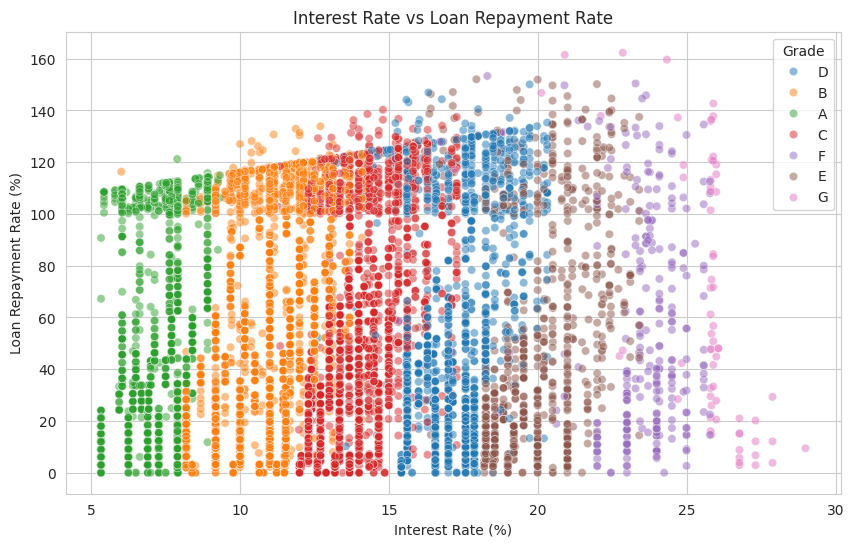

In [46]:
scatter_data = loan_data[
    (loan_data["loan_repayment_rate"] <= 250) &
    (loan_data["funded_amnt"].notnull()) &
    (loan_data["int_rate"].notnull())
]

scatter_sample = scatter_data.sample(n=min(10000, len(scatter_data)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_sample,
    x="int_rate",
    y="loan_repayment_rate",
    hue="grade",
    alpha=0.5
)
plt.title("Interest Rate vs Loan Repayment Rate")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Loan Repayment Rate (%)")
plt.legend(title="Grade")
plt.show()

**DTI vs Loan Repayment Rate**

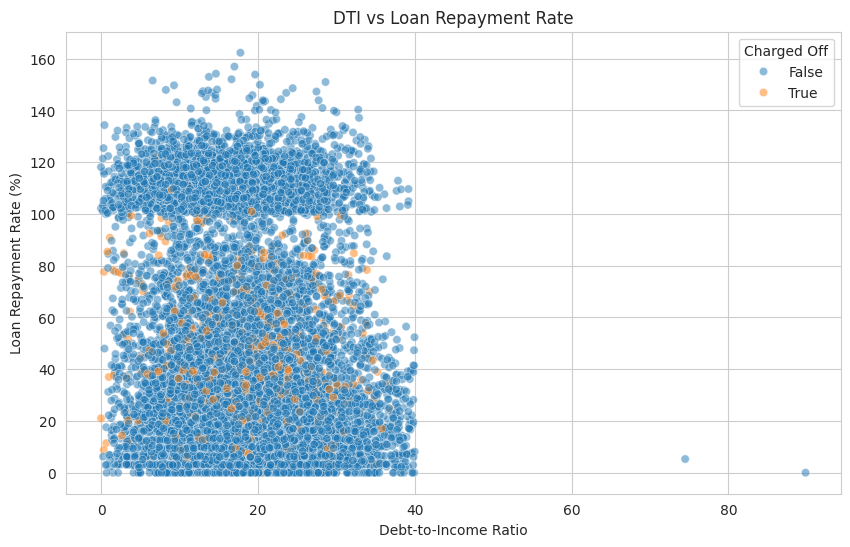

In [47]:
dti_scatter_data = loan_data[
    (loan_data["dti"] <= 100) &
    (loan_data["loan_repayment_rate"] <= 250)
]

dti_sample = dti_scatter_data.sample(n=min(10000, len(dti_scatter_data)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dti_sample,
    x="dti",
    y="loan_repayment_rate",
    hue="is_charged_off",
    alpha=0.5
)
plt.title("DTI vs Loan Repayment Rate")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Loan Repayment Rate (%)")
plt.legend(title="Charged Off")
plt.show()

**Loan Term vs Default Rate**

/tmp/ipykernel_474/767429443.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_term_default, x="term", y="default_rate", palette="magma")


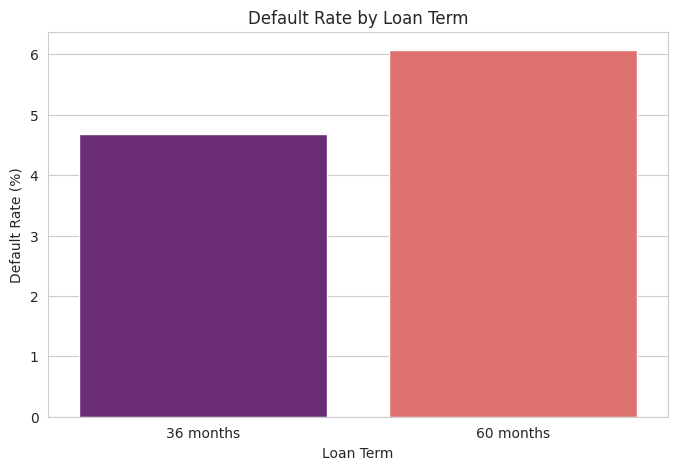

In [48]:
eda_term_default = loan_data.groupby("term", dropna=False)["is_charged_off"].mean().reset_index()
eda_term_default["default_rate"] = eda_term_default["is_charged_off"] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=eda_term_default, x="term", y="default_rate", palette="magma")
plt.title("Default Rate by Loan Term")
plt.xlabel("Loan Term")
plt.ylabel("Default Rate (%)")
plt.show()

**4.3 Multivariate Analysis**

**Correlation Heatmap for Numeric Variables**

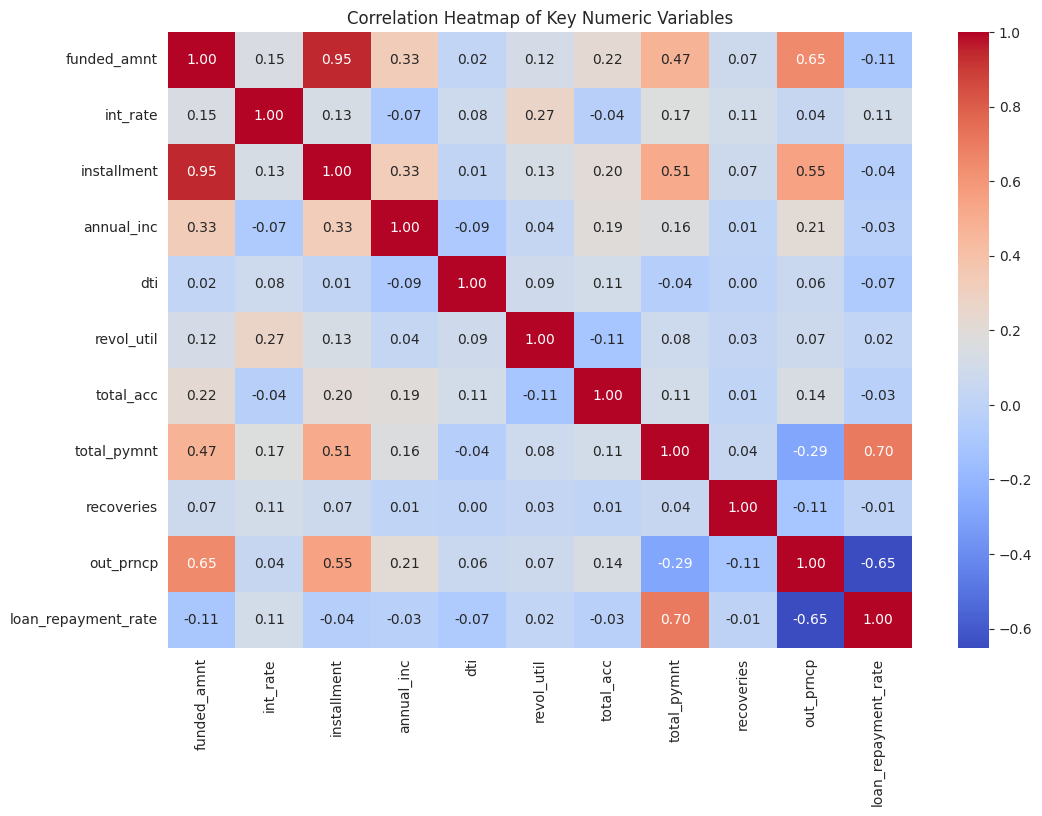

In [49]:
correlation_columns = [
    "funded_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "revol_util",
    "total_acc",
    "total_pymnt",
    "recoveries",
    "out_prncp",
    "loan_repayment_rate"
]

correlation_data = loan_data[correlation_columns].copy()
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Numeric Variables")
plt.show()

**Grade and Term Interaction: Default Rate**

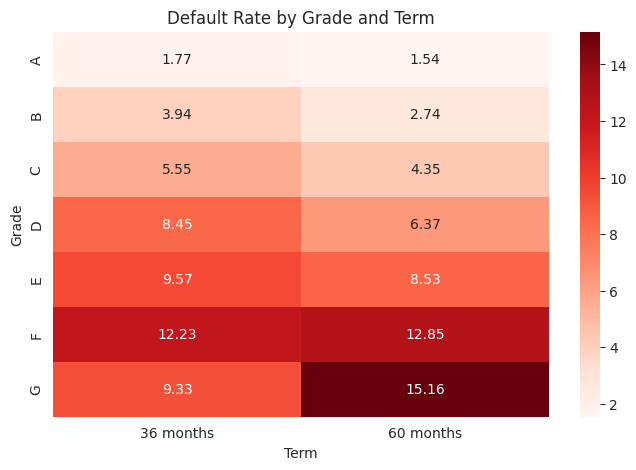

In [50]:
grade_term_default = loan_data.pivot_table(
    index="grade",
    columns="term",
    values="is_charged_off",
    aggfunc="mean"
) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(grade_term_default, annot=True, cmap="Reds", fmt=".2f")
plt.title("Default Rate by Grade and Term")
plt.xlabel("Term")
plt.ylabel("Grade")
plt.show()

**Grade and DTI Band Interaction: Loan Repayment Rate**

/tmp/ipykernel_474/101116953.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  grade_dti_lrr = loan_data.pivot_table(


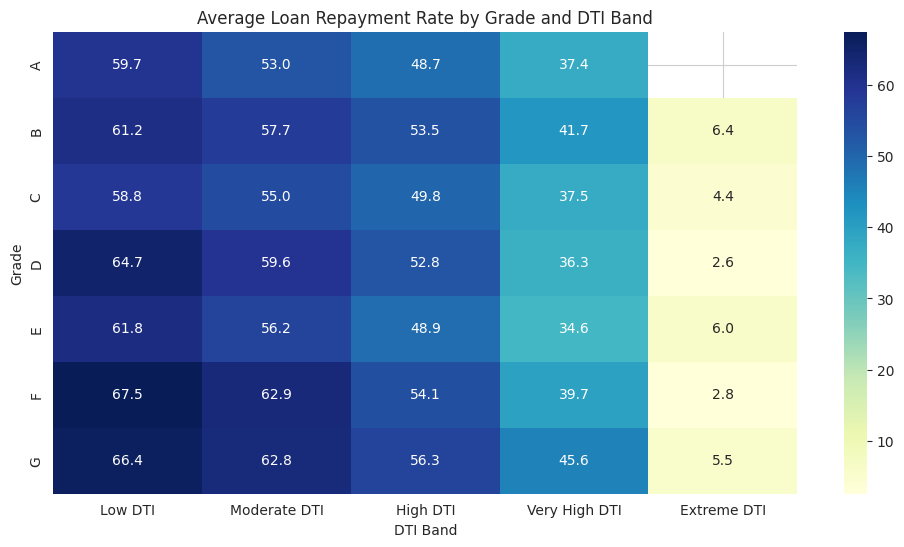

In [51]:
grade_dti_lrr = loan_data.pivot_table(
    index="grade",
    columns="dti_band",
    values="loan_repayment_rate",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(grade_dti_lrr, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Average Loan Repayment Rate by Grade and DTI Band")
plt.xlabel("DTI Band")
plt.ylabel("Grade")
plt.show()

**Grade, Term, and Interest Rate Relationship**

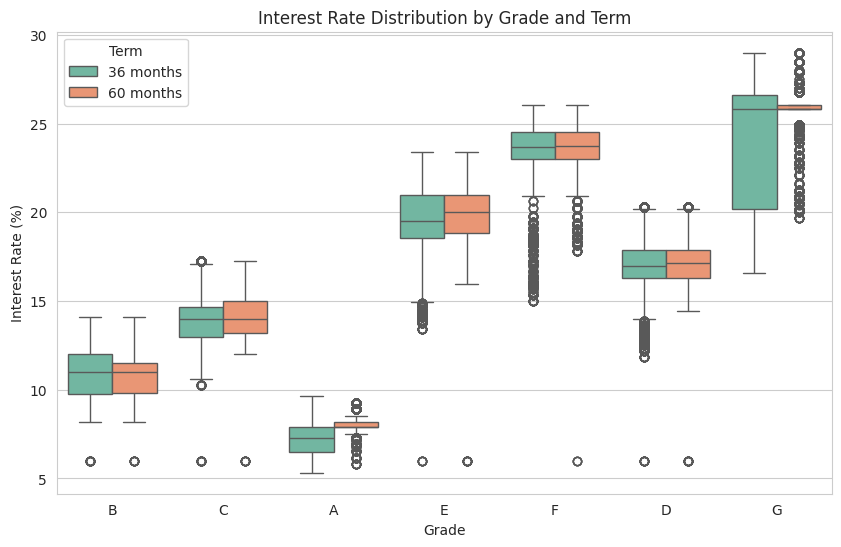

In [52]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=loan_data, x="grade", y="int_rate", hue="term", palette="Set2")
plt.title("Interest Rate Distribution by Grade and Term")
plt.xlabel("Grade")
plt.ylabel("Interest Rate (%)")
plt.legend(title="Term")
plt.show()

**Income Band, DTI Band, and Default Risk**

/tmp/ipykernel_474/1820397777.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  income_dti_default = loan_data.pivot_table(


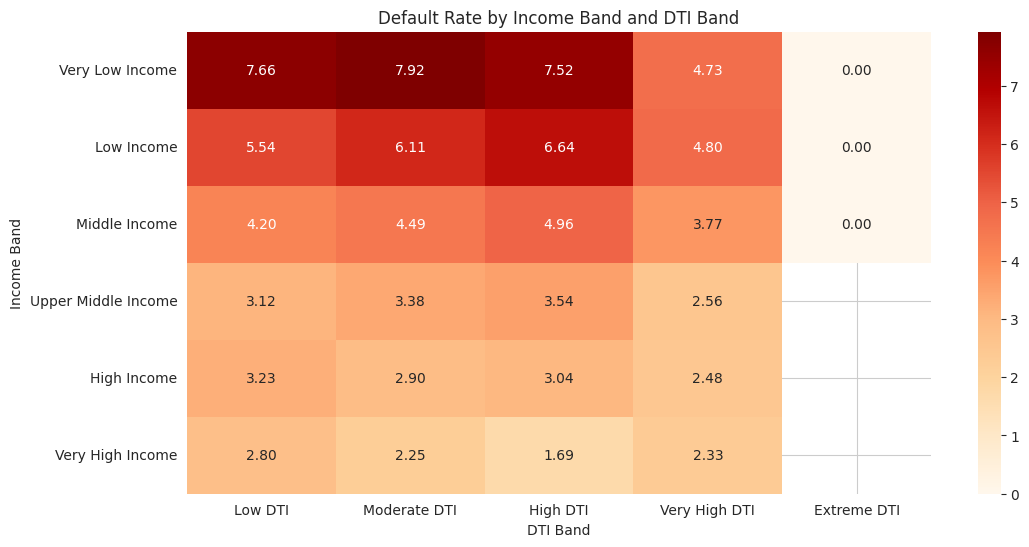

In [53]:
income_dti_default = loan_data.pivot_table(
    index="income_band",
    columns="dti_band",
    values="is_charged_off",
    aggfunc="mean"
) * 100

plt.figure(figsize=(12, 6))
sns.heatmap(income_dti_default, annot=True, cmap="OrRd", fmt=".2f")
plt.title("Default Rate by Income Band and DTI Band")
plt.xlabel("DTI Band")
plt.ylabel("Income Band")
plt.show()

**EDA Summary**

In [54]:
print("EDA Summary")
print("-----------")
print("1. Univariate analysis shows the distribution and outlier behaviour of funded amount, interest rate, DTI, annual income, and repayment rate.")
print("2. Bivariate analysis compares repayment and default behaviour across grade, term, interest rate, and DTI.")
print("3. Multivariate analysis uses heatmaps and grouped charts to evaluate how grade, term, DTI band, and income band interact with default risk and LRR.")
print("4. These EDA outputs support the business objective by identifying the borrower and loan segments most strongly linked with repayment performance.")

EDA Summary
-----------
1. Univariate analysis shows the distribution and outlier behaviour of funded amount, interest rate, DTI, annual income, and repayment rate.
2. Bivariate analysis compares repayment and default behaviour across grade, term, interest rate, and DTI.
3. Multivariate analysis uses heatmaps and grouped charts to evaluate how grade, term, DTI band, and income band interact with default risk and LRR.
4. These EDA outputs support the business objective by identifying the borrower and loan segments most strongly linked with repayment performance.


## ***5.KPI Analysis***

In [55]:
kpi_formula_reference = pd.DataFrame({
    "KPI": [
        "Loan Repayment Rate",
        "Default Rate",
        "Average Interest Rate by Grade",
        "Average Interest Rate by Sub-grade",
        "Recovery Rate on Defaulted Loans"
    ],
    "Formula": [
        "(Total Amount Repaid / Total Amount Funded) * 100",
        "(Charged Off Loans / Total Loans Issued) * 100",
        "Mean int_rate grouped by grade",
        "Mean int_rate grouped by sub_grade",
        "(Recoveries / Outstanding Principal) * 100 for charged-off loans"
    ],
    "Columns Used": [
        "total_pymnt, funded_amnt",
        "loan_status",
        "grade, int_rate",
        "sub_grade, int_rate",
        "loan_status, recoveries, out_prncp"
    ],
    "Business Purpose": [
        "Measures how much of the funded amount has been recovered through borrower payments.",
        "Measures the share of loans that became credit losses.",
        "Evaluates whether pricing increases with borrower risk grade.",
        "Evaluates pricing effectiveness at a more granular risk level.",
        "Measures post-default recovery efficiency."
    ]
})

kpi_formula_reference

,KPI,Formula,Columns Used,Business Purpose
0,Loan Repayment Rate,(Total Amount Repaid / Total Amount Funded) * 100,"total_pymnt, funded_amnt",Measures how much of the funded amount has bee...
1,Default Rate,(Charged Off Loans / Total Loans Issued) * 100,loan_status,Measures the share of loans that became credit...
2,Average Interest Rate by Grade,Mean int_rate grouped by grade,"grade, int_rate",Evaluates whether pricing increases with borro...
3,Average Interest Rate by Sub-grade,Mean int_rate grouped by sub_grade,"sub_grade, int_rate",Evaluates pricing effectiveness at a more gran...
4,Recovery Rate on Defaulted Loans,(Recoveries / Outstanding Principal) * 100 for...,"loan_status, recoveries, out_prncp",Measures post-default recovery efficiency.


In [56]:
# Overall Loan Repayment Rate
total_amount_repaid = loan_data["total_pymnt"].sum()
total_amount_funded = loan_data["funded_amnt"].sum()
overall_lrr = (total_amount_repaid / total_amount_funded) * 100

print(f"Total Amount Repaid: {total_amount_repaid:,.2f}")
print(f"Total Amount Funded: {total_amount_funded:,.2f}")
print(f"Overall Loan Repayment Rate: {overall_lrr:.2f}%")

Total Amount Repaid: 6,707,544,063.70
Total Amount Funded: 13,081,632,625.00
Overall Loan Repayment Rate: 51.27%


In [57]:
# Default Rate
total_loans = len(loan_data)
charged_off_loans = loan_data["is_charged_off"].sum()
default_rate = (charged_off_loans / total_loans) * 100

print(f"Total Loans: {total_loans:,}")
print(f"Charged Off Loans: {charged_off_loans:,}")
print(f"Default Rate: {default_rate:.2f}%")

Total Loans: 887,379
Charged Off Loans: 45,248
Default Rate: 5.10%


In [58]:
# Average Interest Rate by Grade
avg_interest_by_grade = loan_data.groupby("grade", dropna=False).agg(
    loan_count=("id", "count"),
    avg_interest_rate=("int_rate", "mean"),
    avg_lrr=("loan_repayment_rate", "mean"),
    default_rate=("is_charged_off", "mean")
).reset_index()

avg_interest_by_grade["default_rate"] = avg_interest_by_grade["default_rate"] * 100
avg_interest_by_grade = avg_interest_by_grade.sort_values(by="grade")

avg_interest_by_grade

,grade,loan_count,avg_interest_rate,avg_lrr,default_rate
0,A,148202,7.243312,53.140470,1.765833
1,B,254535,10.829618,56.126128,3.739761
2,C,245860,13.980098,52.070754,5.141951
3,D,139542,17.175814,54.613066,7.514583
4,E,70705,19.897322,51.013370,8.850859
5,F,23046,23.582787,57.380911,12.731060
6,G,5489,25.626706,59.305990,14.428858


In [59]:
# Average Interest Rate by Sub-grade
avg_interest_by_subgrade = loan_data.groupby("sub_grade", dropna=False).agg(
    loan_count=("id", "count"),
    avg_interest_rate=("int_rate", "mean"),
    avg_lrr=("loan_repayment_rate", "mean"),
    default_rate=("is_charged_off", "mean")
).reset_index()

avg_interest_by_subgrade["default_rate"] = avg_interest_by_subgrade["default_rate"] * 100
avg_interest_by_subgrade = avg_interest_by_subgrade.sort_values(by="sub_grade")

avg_interest_by_subgrade

,sub_grade,loan_count,avg_interest_rate,avg_lrr,default_rate
0,A1,22913,5.712019,48.191483,0.789945
1,A2,22485,6.425859,51.685298,1.231932
2,A3,23457,7.141020,55.889531,1.700985
3,A4,34531,7.529181,57.165083,2.255944
4,A5,44816,8.269620,51.860951,2.188950
5,B1,44972,8.948791,52.539543,2.697234
6,B2,48781,9.996643,56.870246,3.265616
7,B3,56323,10.900792,58.542674,4.010795
8,B4,55626,11.744866,57.121899,4.176105
9,B5,48833,12.269169,54.764330,4.363852


In [60]:
# Recovery Rate on Charged-off Loans
charged_off_data = loan_data[loan_data["loan_status"] == "Charged Off"].copy()

charged_off_recoveries = charged_off_data["recoveries"].sum()
charged_off_outstanding_principal = charged_off_data["out_prncp"].sum()
charged_off_funded_amount = charged_off_data["funded_amnt"].sum()
charged_off_nonzero_out_prncp = charged_off_data[charged_off_data["out_prncp"] > 0].copy()
charged_off_zero_out_prncp_count = (charged_off_data["out_prncp"] == 0).sum()

if charged_off_outstanding_principal > 0:
    recovery_rate_on_defaulted_loans = (charged_off_recoveries / charged_off_outstanding_principal) * 100
    recovery_rate_status = "Calculated using recoveries divided by total outstanding principal for charged-off loans."
else:
    recovery_rate_on_defaulted_loans = np.nan
    recovery_rate_status = "Not calculated because total outstanding principal for charged-off loans is zero."

if len(charged_off_nonzero_out_prncp) > 0:
    recovery_rate_nonzero_out_prncp = (
        charged_off_nonzero_out_prncp["recoveries"].sum() /
        charged_off_nonzero_out_prncp["out_prncp"].sum()
    ) * 100
else:
    recovery_rate_nonzero_out_prncp = np.nan

if charged_off_funded_amount > 0:
    recovery_to_funded_defaulted_loans = (charged_off_recoveries / charged_off_funded_amount) * 100
else:
    recovery_to_funded_defaulted_loans = np.nan

recovery_rate_display = (
    "Not applicable - zero outstanding principal"
    if pd.isna(recovery_rate_on_defaulted_loans)
    else f"{recovery_rate_on_defaulted_loans:.2f}%"
)

recovery_nonzero_display = (
    "Not applicable - no charged-off loans with non-zero outstanding principal"
    if pd.isna(recovery_rate_nonzero_out_prncp)
    else f"{recovery_rate_nonzero_out_prncp:.2f}%"
)

recovery_to_funded_display = (
    "Not applicable"
    if pd.isna(recovery_to_funded_defaulted_loans)
    else f"{recovery_to_funded_defaulted_loans:.2f}%"
)

print(f"Recoveries on Charged-off Loans: {charged_off_recoveries:,.2f}")
print(f"Outstanding Principal on Charged-off Loans: {charged_off_outstanding_principal:,.2f}")
print(f"Charged-off Loans with Zero Outstanding Principal: {charged_off_zero_out_prncp_count:,}")
print(f"Project-defined Recovery Rate on Defaulted Loans: {recovery_rate_display}")
print(f"Recovery Rate Status: {recovery_rate_status}")
print(f"Recovery Rate on Charged-off Loans with Non-zero Outstanding Principal: {recovery_nonzero_display}")
print(f"Recovery-to-Funded Amount on Charged-off Loans: {recovery_to_funded_display}")

Recoveries on Charged-off Loans: 40,307,151.71
Outstanding Principal on Charged-off Loans: 0.00
Charged-off Loans with Zero Outstanding Principal: 45,248
Project-defined Recovery Rate on Defaulted Loans: Not applicable - zero outstanding principal
Recovery Rate Status: Not calculated because total outstanding principal for charged-off loans is zero.
Recovery Rate on Charged-off Loans with Non-zero Outstanding Principal: Not applicable - no charged-off loans with non-zero outstanding principal
Recovery-to-Funded Amount on Charged-off Loans: 6.14%


In [61]:
# KPI Summary Table
kpi_summary = pd.DataFrame({
    "KPI": [
        "Loan Repayment Rate",
        "Default Rate",
        "Recovery Rate on Defaulted Loans",
        "Recovery Rate on Non-zero Outstanding Charged-off Loans",
        "Recovery-to-Funded Amount on Charged-off Loans",
        "Average Interest Rate"
    ],
    "Value": [
        f"{overall_lrr:.2f}%",
        f"{default_rate:.2f}%",
        recovery_rate_display,
        recovery_nonzero_display,
        recovery_to_funded_display,
        f"{loan_data['int_rate'].mean():.2f}%"
    ],
    "Business Meaning": [
        "Shows how much of the funded loan amount has been recovered through borrower payments.",
        "Shows the share of loans that were charged off.",
        "Project KPI: recoveries divided by outstanding principal for charged-off loans.",
        "Diagnostic version of the project KPI using only charged-off loans where outstanding principal is greater than zero.",
        "Supporting diagnostic: recoveries divided by funded amount for charged-off loans, useful when out_prncp is zero.",
        "Shows average pricing across the loan book."
    ]
})

kpi_summary

,KPI,Value,Business Meaning
0,Loan Repayment Rate,51.27%,Shows how much of the funded loan amount has b...
1,Default Rate,5.10%,Shows the share of loans that were charged off.
2,Recovery Rate on Defaulted Loans,Not applicable - zero outstanding principal,Project KPI: recoveries divided by outstanding...
3,Recovery Rate on Non-zero Outstanding Charged-...,Not applicable - no charged-off loans with non...,Diagnostic version of the project KPI using on...
4,Recovery-to-Funded Amount on Charged-off Loans,6.14%,Supporting diagnostic: recoveries divided by f...
5,Average Interest Rate,13.25%,Shows average pricing across the loan book.


## ***6.Segment Analysis***

In [62]:
# Loan Performance by Grade
grade_performance = loan_data.groupby("grade", dropna=False).agg(
    loan_count=("id", "count"),
    funded_amount=("funded_amnt", "sum"),
    total_payment=("total_pymnt", "sum"),
    avg_interest_rate=("int_rate", "mean"),
    avg_dti=("dti", "mean"),
    avg_income=("annual_inc", "mean"),
    charged_off_count=("is_charged_off", "sum"),
    late_count=("is_late", "sum")
).reset_index()

grade_performance["loan_repayment_rate"] = (grade_performance["total_payment"] / grade_performance["funded_amount"]) * 100
grade_performance["default_rate"] = (grade_performance["charged_off_count"] / grade_performance["loan_count"]) * 100
grade_performance["late_rate"] = (grade_performance["late_count"] / grade_performance["loan_count"]) * 100
grade_performance = grade_performance.sort_values(by="grade")

grade_performance

,grade,loan_count,funded_amount,total_payment,avg_interest_rate,avg_dti,avg_income,charged_off_count,late_count,loan_repayment_rate,default_rate,late_rate
0,A,148202,2.078285e+09,1.047534e+09,7.243312,15.577401,86942.651653,2617,991,50.403772,1.765833,0.668682
1,B,254535,3.469362e+09,1.849462e+09,10.829618,17.305115,75487.389207,9519,3654,53.308430,3.739761,1.435559
2,C,245860,3.554701e+09,1.764145e+09,13.980098,18.792559,71536.950300,12642,5904,49.628517,5.141951,2.401367
3,D,139542,2.155994e+09,1.105507e+09,17.175814,19.908175,69169.272616,10486,4864,51.275968,7.514583,3.485689
4,E,70705,1.270628e+09,6.266197e+08,19.897322,20.338847,72119.152229,6258,3128,49.315764,8.850859,4.424015
5,F,23046,4.401512e+08,2.470120e+08,23.582787,19.834316,73801.170917,2934,1277,56.119802,12.731060,5.541092
6,G,5489,1.125133e+08,6.726451e+07,25.626706,19.182093,79904.591762,792,383,59.783609,14.428858,6.977592


In [63]:
# Loan Performance by Term
term_performance = loan_data.groupby("term", dropna=False).agg(
    loan_count=("id", "count"),
    funded_amount=("funded_amnt", "sum"),
    total_payment=("total_pymnt", "sum"),
    avg_interest_rate=("int_rate", "mean"),
    charged_off_count=("is_charged_off", "sum")
).reset_index()

term_performance["loan_repayment_rate"] = (term_performance["total_payment"] / term_performance["funded_amount"]) * 100
term_performance["default_rate"] = (term_performance["charged_off_count"] / term_performance["loan_count"]) * 100

term_performance

,term,loan_count,funded_amount,total_payment,avg_interest_rate,charged_off_count,loan_repayment_rate,default_rate
0,36 months,621125,7.748401e+09,4.429048e+09,12.018678,29083,57.160796,4.68231
1,60 months,266254,5.333231e+09,2.278496e+09,16.111596,16165,42.722621,6.07127


In [64]:
# Loan Performance by Income Band
income_performance = loan_data.groupby("income_band", dropna=False).agg(
    loan_count=("id", "count"),
    funded_amount=("funded_amnt", "sum"),
    total_payment=("total_pymnt", "sum"),
    avg_interest_rate=("int_rate", "mean"),
    avg_dti=("dti", "mean"),
    charged_off_count=("is_charged_off", "sum")
).reset_index()

income_performance["loan_repayment_rate"] = (income_performance["total_payment"] / income_performance["funded_amount"]) * 100
income_performance["default_rate"] = (income_performance["charged_off_count"] / income_performance["loan_count"]) * 100

income_performance

/tmp/ipykernel_474/1802576952.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_performance = loan_data.groupby("income_band", dropna=False).agg(


,income_band,loan_count,funded_amount,total_payment,avg_interest_rate,avg_dti,charged_off_count,loan_repayment_rate,default_rate
0,Very Low Income,64292,4.325073e+08,2.324422e+08,14.019092,20.320129,4661,53.742958,7.249736
1,Low Income,351195,4.074612e+09,2.146459e+09,13.606283,19.560473,21285,52.678855,6.060735
2,Middle Income,314125,5.226820e+09,2.675949e+09,13.074471,17.799068,14228,51.196508,4.529407
3,Upper Middle Income,114431,2.332461e+09,1.159725e+09,12.540808,15.668417,3802,49.721081,3.322526
4,High Income,35365,8.126480e+08,3.961272e+08,12.315520,13.352552,1071,48.745243,3.028418
5,Very High Income,7967,2.025590e+08,9.681315e+07,12.232876,10.029857,201,47.795026,2.522907
6,NaN,4,2.520000e+04,2.836524e+04,7.827500,1.750000,0,112.560476,0.000000


In [65]:
# Loan Performance by DTI Band
dti_performance = loan_data.groupby("dti_band", dropna=False).agg(
    loan_count=("id", "count"),
    funded_amount=("funded_amnt", "sum"),
    total_payment=("total_pymnt", "sum"),
    avg_interest_rate=("int_rate", "mean"),
    avg_income=("annual_inc", "mean"),
    charged_off_count=("is_charged_off", "sum")
).reset_index()

dti_performance["loan_repayment_rate"] = (dti_performance["total_payment"] / dti_performance["funded_amount"]) * 100
dti_performance["default_rate"] = (dti_performance["charged_off_count"] / dti_performance["loan_count"]) * 100

dti_performance

/tmp/ipykernel_474/3775268447.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_performance = loan_data.groupby("dti_band", dropna=False).agg(


,dti_band,loan_count,funded_amount,total_payment,avg_interest_rate,avg_income,charged_off_count,loan_repayment_rate,default_rate
0,Low DTI,158103,2.147957e+09,1.243617e+09,12.393789,93090.860990,7183,57.897671,4.543241
1,Moderate DTI,375601,5.623983e+09,3.026894e+09,12.929279,77959.082241,18853,53.821177,5.019422
2,High DTI,272685,4.123373e+09,2.011025e+09,13.667180,65697.451244,15697,48.771356,5.756459
3,Very High DTI,80900,1.184750e+09,4.259579e+08,14.964826,57611.801732,3515,35.953396,4.344870
4,Extreme DTI,90,1.568775e+06,4.994111e+04,18.264000,33557.292444,0,3.183446,0.000000


In [66]:
# Loan Performance by Purpose
purpose_performance = loan_data.groupby("purpose", dropna=False).agg(
    loan_count=("id", "count"),
    funded_amount=("funded_amnt", "sum"),
    total_payment=("total_pymnt", "sum"),
    avg_interest_rate=("int_rate", "mean"),
    charged_off_count=("is_charged_off", "sum")
).reset_index()

purpose_performance["loan_repayment_rate"] = (purpose_performance["total_payment"] / purpose_performance["funded_amount"]) * 100
purpose_performance["default_rate"] = (purpose_performance["charged_off_count"] / purpose_performance["loan_count"]) * 100
purpose_performance = purpose_performance.sort_values(by="loan_count", ascending=False)

purpose_performance

,purpose,loan_count,funded_amount,total_payment,avg_interest_rate,charged_off_count,loan_repayment_rate,default_rate
2,debt_consolidation,524215,8.081531e+09,4.156187e+09,13.601379,27599,51.428207,5.264825
1,credit_card,206182,3.161033e+09,1.520739e+09,11.773691,7826,48.108907,3.795676
4,home_improvement,51829,7.412210e+08,3.826344e+08,13.027068,2269,51.622170,4.377858
9,other,42894,4.234072e+08,2.351690e+08,15.021655,2936,55.542036,6.844780
6,major_purchase,17277,1.999837e+08,1.076378e+08,12.673565,874,53.823293,5.058749
11,small_business,10377,1.589524e+08,1.052378e+08,16.233037,1371,66.207121,13.211911
0,car,8863,7.862628e+07,4.677654e+07,12.005558,448,59.492247,5.054722
7,medical,8540,7.690318e+07,4.189326e+07,14.562644,569,54.475332,6.662763
8,moving,5414,4.264148e+07,2.461633e+07,15.729104,425,57.728604,7.850018
12,vacation,4736,2.975530e+07,1.630068e+07,14.340332,270,54.782434,5.701014


In [67]:
# Loan Performance by Verification Status
verification_performance = loan_data.groupby("verification_status", dropna=False).agg(
    loan_count=("id", "count"),
    funded_amount=("funded_amnt", "sum"),
    total_payment=("total_pymnt", "sum"),
    avg_interest_rate=("int_rate", "mean"),
    avg_income=("annual_inc", "mean"),
    charged_off_count=("is_charged_off", "sum")
).reset_index()

verification_performance["loan_repayment_rate"] = (verification_performance["total_payment"] / verification_performance["funded_amount"]) * 100
verification_performance["default_rate"] = (verification_performance["charged_off_count"] / verification_performance["loan_count"]) * 100

verification_performance

,verification_status,loan_count,funded_amount,total_payment,avg_interest_rate,avg_income,charged_off_count,loan_repayment_rate,default_rate
0,Not Verified,266750,2.978765e+09,1.545482e+09,11.786074,66771.929283,12208,51.883331,4.576570
1,Source Verified,329558,5.105596e+09,2.253564e+09,13.258772,78915.817879,13740,44.139106,4.169221
2,Verified,291071,4.997272e+09,2.908497e+09,14.571733,78190.962109,19300,58.201700,6.630685


## ***7. Data Visualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

**Bar Chart for Loan Distribution by Grade**

/tmp/ipykernel_474/2893041188.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette="viridis")


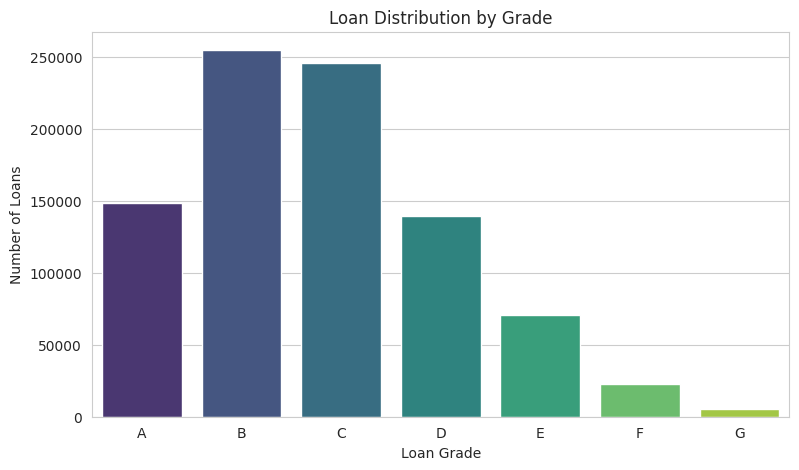

In [68]:
# Dataset Copy
chart_data = loan_data.copy()

grade_counts = chart_data["grade"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette="viridis")
plt.title("Loan Distribution by Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Loans")
plt.show()

1. Why did I choose this chart?

    Loan grade is one of the most important risk indicators in the dataset. A grade-wise distribution helps us understand where the bank's loan exposure is concentrated.

2. Insight(s) found from the chart?

    The output shows whether the loan book is concentrated in lower-risk grades such as A and B or riskier grades such as E, F, and G.

3. Insights and Business Impact?

    If a large share of funded loans sits in riskier grades, UCUCI Bank should strengthen monitoring, provisioning, and pricing for those segments.

**Bar Chart for Default Rate by Grade**

/tmp/ipykernel_474/65253341.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_by_grade.index, y=default_by_grade.values, palette="rocket")


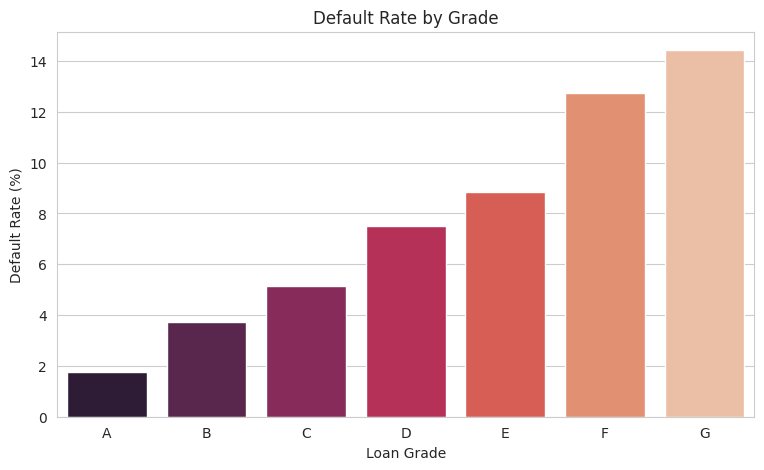

In [69]:
# Dataset Copy
chart_data = loan_data.copy()

default_by_grade = chart_data.groupby("grade")["is_charged_off"].mean().sort_index() * 100

plt.figure(figsize=(9, 5))
sns.barplot(x=default_by_grade.index, y=default_by_grade.values, palette="rocket")
plt.title("Default Rate by Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")
plt.show()

1. Why did I choose this chart?

    Default rate by grade directly shows whether risk grades are correctly separating safer borrowers from riskier borrowers.

2. Insight(s) found from the chart?

    The expected pattern is that default rates increase from grade A to grade G. Any unexpected reversal may indicate pricing or underwriting issues.

3. Insights and Business Impact?

    If lower grades show sharply higher defaults, the bank should apply stricter approval rules, higher pricing, or smaller loan limits in those grades.

**Bar Chart for Loan Repayment Rate by Grade**

/tmp/ipykernel_474/3675195001.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lrr_by_grade = chart_data.groupby("grade").apply(
/tmp/ipykernel_474/3675195001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lrr_by_grade.index, y=lrr_by_grade.values, palette="mako")


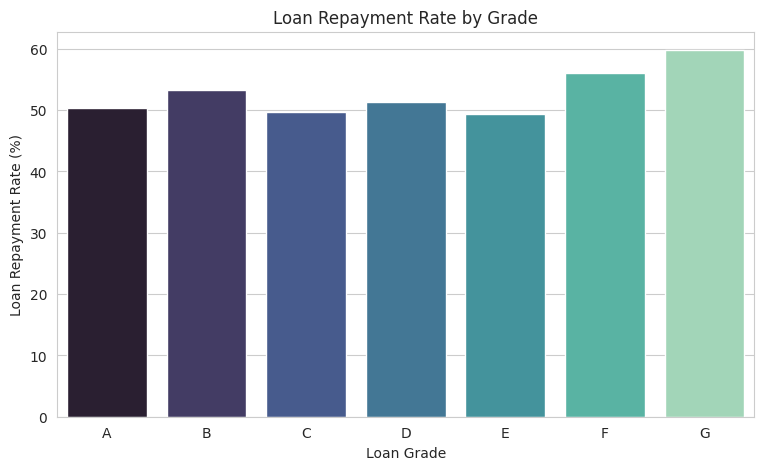

In [70]:
# Dataset Copy
chart_data = loan_data.copy()

lrr_by_grade = chart_data.groupby("grade").apply(
    lambda x: (x["total_pymnt"].sum() / x["funded_amnt"].sum()) * 100
).sort_index()

plt.figure(figsize=(9, 5))
sns.barplot(x=lrr_by_grade.index, y=lrr_by_grade.values, palette="mako")
plt.title("Loan Repayment Rate by Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Loan Repayment Rate (%)")
plt.show()

1. Why did I choose this chart?

    LRR is the key metric for the project. Viewing it by grade helps identify which grades support or reduce repayment performance.
2. Insight(s) found from the chart?

    Grades with lower LRR may be contributing more to repayment weakness and should be reviewed for pricing and approval policy.
3. Insights and Business Impact?

    Improving LRR in weak grades can directly improve portfolio health and reduce credit losses.

**Bar Chart for Default Rate by Purpose**

/tmp/ipykernel_474/2256087785.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=purpose_default, x="default_rate", y="purpose", palette="flare")


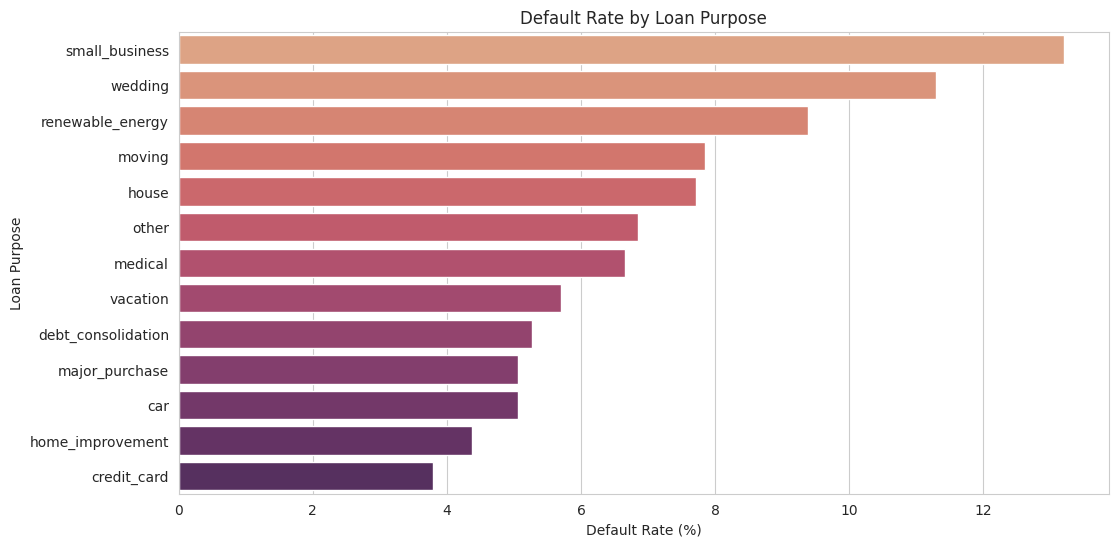

In [71]:
# Dataset Copy
chart_data = loan_data.copy()

purpose_default = chart_data.groupby("purpose").agg(
    loan_count=("id", "count"),
    default_rate=("is_charged_off", "mean")
).reset_index()

purpose_default["default_rate"] = purpose_default["default_rate"] * 100
purpose_default = purpose_default[purpose_default["loan_count"] >= 500]
purpose_default = purpose_default.sort_values(by="default_rate", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=purpose_default, x="default_rate", y="purpose", palette="flare")
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")
plt.show()

1. Why did I choose this chart?

    Loan purpose can reveal borrower intent and risk differences between debt consolidation, credit card refinancing, business loans, and other purposes.
2. Insight(s) found from the chart?

    Purposes with high default rates may require tighter approval checks or different pricing.
3. Insights and Business Impact?

    Purpose-based risk rules can help UCUCI Bank reduce defaults without rejecting all borrowers broadly.

## **8.Key Findings and Recommendations**

In [72]:
print("Key Observations and Insights")
print("--------------------------------")
print(f"1. Overall Loan Repayment Rate is {overall_lrr:.2f}%.")
print(f"2. Overall Default Rate is {default_rate:.2f}%.")
print(f"3. Average Interest Rate is {loan_data['int_rate'].mean():.2f}%.")
print(f"4. Charged-off loan count is {charged_off_loans:,}.")
print(f"5. Project-defined Recovery Rate on Defaulted Loans: {recovery_rate_display}.")
print(f"6. Recovery-to-Funded Amount on Charged-off Loans: {recovery_to_funded_display}.")
print(f"7. Recovery note: {recovery_rate_status}")

print("\nGrade Performance Summary:")
print(grade_performance[["grade", "loan_count", "loan_repayment_rate", "default_rate", "avg_interest_rate"]])

Key Observations and Insights
--------------------------------
1. Overall Loan Repayment Rate is 51.27%.
2. Overall Default Rate is 5.10%.
3. Average Interest Rate is 13.25%.
4. Charged-off loan count is 45,248.
5. Project-defined Recovery Rate on Defaulted Loans: Not applicable - zero outstanding principal.
6. Recovery-to-Funded Amount on Charged-off Loans: 6.14%.
7. Recovery note: Not calculated because total outstanding principal for charged-off loans is zero.

Grade Performance Summary:
  grade  loan_count  loan_repayment_rate  default_rate  avg_interest_rate
0     A      148202            50.403772      1.765833           7.243312
1     B      254535            53.308430      3.739761          10.829618
2     C      245860            49.628517      5.141951          13.980098
3     D      139542            51.275968      7.514583          17.175814
4     E       70705            49.315764      8.850859          19.897322
5     F       23046            56.119802     12.731060      

In [73]:
# Automatically identifying strongest and weakest repayment grades
best_lrr_grade = grade_performance.sort_values(by="loan_repayment_rate", ascending=False).head(1)
worst_lrr_grade = grade_performance.sort_values(by="loan_repayment_rate", ascending=True).head(1)
highest_default_grade = grade_performance.sort_values(by="default_rate", ascending=False).head(1)

print("Best Repayment Grade:")
print(best_lrr_grade[["grade", "loan_repayment_rate", "default_rate", "avg_interest_rate"]])

print("\nWeakest Repayment Grade:")
print(worst_lrr_grade[["grade", "loan_repayment_rate", "default_rate", "avg_interest_rate"]])

print("\nHighest Default Grade:")
print(highest_default_grade[["grade", "loan_repayment_rate", "default_rate", "avg_interest_rate"]])

Best Repayment Grade:
  grade  loan_repayment_rate  default_rate  avg_interest_rate
6     G            59.783609     14.428858          25.626706

Weakest Repayment Grade:
  grade  loan_repayment_rate  default_rate  avg_interest_rate
4     E            49.315764      8.850859          19.897322

Highest Default Grade:
  grade  loan_repayment_rate  default_rate  avg_interest_rate
6     G            59.783609     14.428858          25.626706


In [74]:
print("Conclusion")
print("----------")
print("The UCUCI loan dataset is suitable for analyzing repayment performance, default risk, grade-based pricing, and recovery efficiency.")
print("The most important business metric is Loan Repayment Rate, supported by Default Rate, Average Interest Rate by Grade, and Recovery Rate on Defaulted Loans.")
print("Risk grades, sub-grades, loan term, DTI, income band, purpose, and verification status should be used as key segmentation variables.")

Conclusion
----------
The UCUCI loan dataset is suitable for analyzing repayment performance, default risk, grade-based pricing, and recovery efficiency.
The most important business metric is Loan Repayment Rate, supported by Default Rate, Average Interest Rate by Grade, and Recovery Rate on Defaulted Loans.
Risk grades, sub-grades, loan term, DTI, income band, purpose, and verification status should be used as key segmentation variables.


### ***Solution to Business Objective***

The business objective is to improve UCUCI Bank's Loan Repayment Rate (LRR) while controlling default risk, strengthening recovery performance, and making grade-based pricing more effective. Based on the KPI analysis and EDA, the solution should not be limited to one action. It should be a portfolio-level action plan across underwriting, pricing, monitoring, collections, and growth strategy.




####***1.Strengthen Credit Approval for High-Risk Segments :***

**Business Issue:**
  Some borrower segments are likely to show weaker repayment behaviour, especially loans with higher DTI, weaker grades, longer terms, or riskier purposes.

**Recommended Action:**

  UCUCI Bank should tighten approval rules for segments with:

*   High default rate
*   Low Loan Repayment Rate
*   High DTI bands
*   Lower grades and sub-grades
*   Long loan terms with weak repayment performance
*   Purposes showing above-average default risk

**How Stakeholders Can Use This:**

  The Risk Analytics and Credit Policy teams can use the grade, DTI, income, purpose, and term-level summaries to define stricter cut-offs for risky borrowers. For example, borrowers in high DTI bands and lower grades may require additional income verification, lower approved amounts, or shorter repayment terms.

**Expected Business Impact:**

  This will reduce the number of loans issued to borrowers with weak repayment capacity, helping lower future charge-offs and improving overall LRR.


#### ***2. Improve Grade-Based and Sub-Grade-Based Risk Pricing :***

**Business Issue:**
  Interest rate should increase as borrower risk increases. If risky grades have high default rates but interest rates do not sufficiently compensate for the risk, the bank may face weak profitability and higher credit losses.

**Recommended Action:**

  UCUCI Bank should compare:

*   Average interest rate by grade and sub-grade
*   Default rate by grade and sub-grade
*   LRR by grade and sub-grade
*   Recovery performance by grade

    If any sub-grade shows high default risk and low LRR, the bank should review whether the interest rate is high enough or whether approval criteria should be tightened.

**How Stakeholders Can Use This:**

  The Risk Pricing team can use the sub-grade analysis to recalibrate pricing. Strong-performing sub-grades can remain competitively priced, while weak-performing sub-grades may need higher pricing, reduced exposure, or additional approval checks.
**Expected Business Impact:**

Better risk-based pricing will help the bank balance growth and risk, improve profitability, and ensure that higher-risk borrowers are priced appropriately.


####***3. Build an Early Warning Monitoring Framework :***

**Business Issue:**
  Waiting until a loan becomes charged off is too late. UCUCI Bank needs to identify repayment stress earlier, especially among loans that are late, in grace period, or showing weak repayment behaviour.

**Recommended Action:**

  The bank should monitor early warning indicators such as:
*   Loan status moving from Current to In Grace Period
*   Late 16-30 days
*   Late 31-120 days
*   High DTI
*   High revolving utilization
*   Low LRR during the loan life cycle
*   Lower grade combined with longer term

**How Stakeholders Can Use This:**

  The Collections and Portfolio Monitoring teams can prioritize borrowers who show early signs of stress. These customers can be contacted earlier with repayment reminders, restructuring options, or payment support.

**Expected Business Impact:**

  Early intervention can prevent loans from moving into severe delinquency or charge-off, directly supporting improvement in LRR.

####***4. Optimize Loan Amount and Term Strategy :***

**Business Issue:**
  Large loan amounts and longer loan terms may increase repayment pressure, especially for borrowers with high DTI or weaker grades.

**Recommended Action:**

  UCUCI Bank should review loan performance by:
*   Funded amount
*   Term
*   Grade
*   DTI band
*   Income band

    For risky borrowers, the bank can consider approving lower loan amounts, shorter terms, or requiring stronger verification.

**How Stakeholders Can Use This:**

  Credit Underwriting teams can create rules such as lower maximum loan amounts for high-DTI borrowers or stricter term approvals for lower-grade customers.

**Expected Business Impact:**

  Better alignment between borrower repayment capacity and loan structure can reduce default risk and improve repayment consistency.


####***5. Improve Recovery Strategy for Charged-Off Loans :***

**Business Issue:**
  Charged-off loans reduce portfolio health. Even after default, recovery performance matters because recoveries reduce final credit losses.

**Recommended Action:**

  UCUCI Bank should analyze recovery performance by:
*   Grade
*   Sub Grade
*   Purpose
*   Term
*   DTI band
*   Income band

    Segments with low recovery rates should receive more focused recovery strategies, such as earlier settlement offers, specialized recovery teams, or stronger legal follow-up where appropriate.

**How Stakeholders Can Use This:**

 The Collections and Recovery teams can prioritize charged-off accounts where expected recovery is higher and redesign strategies for segments where recovery is consistently weak.

**Expected Business Impact:**

  Improved recovery efficiency will reduce net credit loss and improve the bank's provisioning position.


####***6. Focus Growth on Healthy Portfolio Segments :***

**Business Issue:**
 The goal is not only to reduce risk but also to grow sustainably. Some borrower segments may show strong LRR, low default rate, and acceptable interest income.

**Recommended Action:**

  UCUCI Bank should identify and grow segments with:

*   High LRR
*   Low default rate
*   Stable income profile
*   Moderate DTI
*   Strong grades and sub-grades
*   Good repayment performance across terms

**How Stakeholders Can Use This:**

  The Business and Product teams can design targeted campaigns for healthier borrower segments, while avoiding aggressive growth in weak-performing segments.

**Expected Business Impact:**

  This helps the bank grow the loan book without weakening portfolio quality.

####***7. Create a KPI Monitoring Dashboard for Leadership :***

**Business Issue:**
 Stakeholders need a recurring view of portfolio health instead of one-time analysis.

**Recommended Action:**

  The leadership dashboard should track:

*   Overall Loan Repayment Rate
*   Default Rate
*   Average Interest Rate by grade and sub-grade
*   Recovery Rate on Defaulted Loans
*   LRR by grade, term, purpose, DTI band, and income band
*   Delinquency trend by loan status
*   High-risk segment exposure

**How Stakeholders Can Use This:**

  Senior leadership can review the dashboard monthly to track whether portfolio quality is improving or weakening. Risk teams can use it for policy changes, and business teams can use it for controlled growth planning.

**Expected Business Impact:**

  A monitoring dashboard makes the analysis actionable and repeatable, helping the bank respond faster to portfolio deterioration.




## ***9. Final Stakeholder Action Plan***

In [75]:
stakeholder_action_plan = pd.DataFrame({
    "Focus Area": [
        "Credit Approval",
        "Risk Pricing",
        "Early Warning Monitoring",
        "Loan Structure",
        "Collections and Recovery",
        "Growth Strategy",
        "Leadership Dashboard"
    ],
    "Recommended Action": [
        "Tighten approval checks for high-risk grades, high DTI bands, weak purposes, and long-term loans.",
        "Reprice or restrict sub-grades where default risk is high and LRR is weak.",
        "Track loans moving into grace period or late status and intervene earlier.",
        "Align funded amount and term with income, DTI, and grade-level repayment capacity.",
        "Prioritize recovery strategies for charged-off segments with recoverable balances.",
        "Increase focus on segments with high LRR, low default rate, and stable borrower profiles.",
        "Build recurring KPI tracking for LRR, default rate, interest rate, recovery rate, and segment risk."
    ],
    "Primary Stakeholder": [
        "Credit Policy Team",
        "Risk Pricing Team",
        "Portfolio Monitoring Team",
        "Underwriting Team",
        "Collections Team",
        "Business Growth Team",
        "Senior Leadership"
    ],
    "Expected Impact": [
        "Lower future defaults and improve approval quality.",
        "Improve risk-adjusted profitability.",
        "Reduce movement from delinquency to charge-off.",
        "Reduce repayment pressure and improve LRR.",
        "Increase post-default recovery and reduce net credit loss.",
        "Support sustainable portfolio growth.",
        "Enable faster, data-driven decision-making."
    ]
})

stakeholder_action_plan

,Focus Area,Recommended Action,Primary Stakeholder,Expected Impact
0,Credit Approval,"Tighten approval checks for high-risk grades, ...",Credit Policy Team,Lower future defaults and improve approval qua...
1,Risk Pricing,Reprice or restrict sub-grades where default r...,Risk Pricing Team,Improve risk-adjusted profitability.
2,Early Warning Monitoring,Track loans moving into grace period or late s...,Portfolio Monitoring Team,Reduce movement from delinquency to charge-off.
3,Loan Structure,"Align funded amount and term with income, DTI,...",Underwriting Team,Reduce repayment pressure and improve LRR.
4,Collections and Recovery,Prioritize recovery strategies for charged-off...,Collections Team,Increase post-default recovery and reduce net ...
5,Growth Strategy,"Increase focus on segments with high LRR, low ...",Business Growth Team,Support sustainable portfolio growth.
6,Leadership Dashboard,"Build recurring KPI tracking for LRR, default ...",Senior Leadership,"Enable faster, data-driven decision-making."
